# Modelo SIR — Springfield, primavera de 2024

**Métodos de Euler e Runge-Kutta para EDOs** · aplicação a um sistema epidemiológico.

Uma nova variante de influenza apareceu numa cidade de **N = 200.000** habitantes.
A Secretaria de Saúde precisa de uma **curva no tempo** $I(t)$: a altura do pico diz
quantos leitos serão necessários; a data do pico diz *quando*.

O modelo SIR de Kermack–McKendrick descreve a epidemia por três compartimentos:

$$
\frac{dS}{dt} = -\beta\,\frac{S\,I}{N}, \qquad
\frac{dI}{dt} = \beta\,\frac{S\,I}{N} - \gamma\,I, \qquad
\frac{dR}{dt} = \gamma\,I.
$$

O termo $\beta\,SI/N$ é **não-linear** e acopla as equações — não há solução analítica
fechada. Por isso integramos numericamente, comparando **Euler** ($O(h)$) e **RK4** ($O(h^4)$).

> Os métodos vêm do pacote do repositório (`src/`). O notebook só monta o problema,
> chama os integradores e analisa os resultados.

## 1. Setup e import dos métodos

In [17]:
import sys, os
# permite rodar o notebook a partir de notebooks/ importando o pacote src/
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.euler import euler_explicit
from src.runge_kutta import rk4

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Parâmetros de Springfield

Extraídos direto dos dados clínicos da variante:

| Quantidade | Valor | Origem |
|---|---|---|
| População $N$ | 200.000 | cidade |
| Período infeccioso | 5 dias | estudos clínicos |
| $\gamma = 1/5$ | 0,2 por dia | recuperação |
| $R_0$ | 2,0 – 2,8 | outras cidades |
| $\beta = R_0\,\gamma$ | depende de $R_0$ | transmissão |
| Infectados iniciais $I(0)$ | 3 | primeiros confirmados |

Note que $R_0 = \beta/\gamma$: o número médio de pessoas que um infectado contagia
numa população totalmente suscetível.

In [18]:
N      = 200000      # população total
gamma  = 1 / 5         # taxa de recuperação (1/dias de doença)
I0     = 3             # infectados ativos no dia 0
S0     = N - I0        # suscetíveis no dia 0
R0_0   = 0             # recuperados no dia 0
y0     = np.array([S0, I0, R0_0], dtype=float)

T_DAYS = 180           # horizonte de simulação (6 meses)
HOSP_RATE = 0.04       # 4% dos infectados precisam de leito
BEDS   = 600           # capacidade hospitalar da cidade

def make_sir(beta, gamma=gamma, N=N):
    """Devolve f(t, y) do sistema SIR para um dado beta.

    y = [S, I, R]; retorna [dS/dt, dI/dt, dR/dt] como vetor.
    A mesma f serve para Euler e RK4 (ambos vetoriais).
    """
    def f(t, y):
        S, I, R = y
        new_inf = beta * S * I / N
        return np.array([-new_inf,
                         new_inf - gamma * I,
                         gamma * I])
    return f

## 3. Curvas S, I, R — visão completa da epidemia

O gráfico clássico do modelo SIR mostra os três compartimentos juntos:
**suscetíveis** caindo, **infectados** subindo até o pico e depois caindo,
**recuperados** acumulando. A área sob $I(t)$ é proporcional ao total de casos;
a interseção $S = R$ marca o pico de $I$.

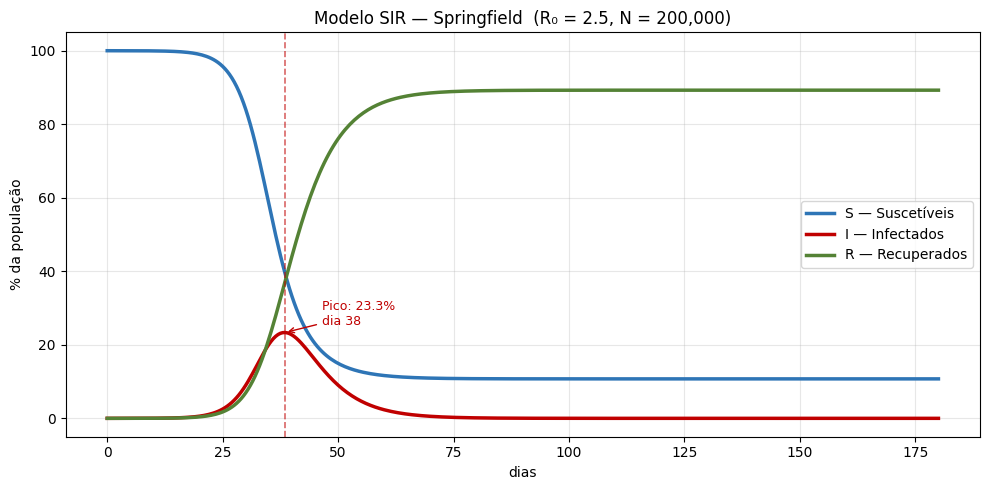

Suscetíveis ao fim:     21,471  (10.7%)
Recuperados ao fim:    178,529  (89.3%)
Pico de infectados:     46,691  (23.3%)  no dia 38


In [19]:
R0_central = 2.5
beta_central = R0_central * gamma
f_central = make_sir(beta_central)

h_vis = 0.5
n_vis = int(T_DAYS / h_vis)
t_vis, y_vis = rk4(f_central, 0.0, y0, h_vis, n_vis)

S_vis = y_vis[:, 0]
I_vis = y_vis[:, 1]
R_vis = y_vis[:, 2]

ipk = I_vis.argmax()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_vis, S_vis / N * 100, color="#2E75B6", lw=2.5, label="S — Suscetíveis")
ax.plot(t_vis, I_vis / N * 100, color="#C00000", lw=2.5, label="I — Infectados")
ax.plot(t_vis, R_vis / N * 100, color="#548235", lw=2.5, label="R — Recuperados")

# marca o pico de I
ax.axvline(t_vis[ipk], color="#C00000", ls="--", lw=1.2, alpha=0.6)
ax.annotate(
    f"Pico: {I_vis[ipk]/N*100:.1f}%\ndia {t_vis[ipk]:.0f}",
    xy=(t_vis[ipk], I_vis[ipk] / N * 100),
    xytext=(t_vis[ipk] + 8, I_vis[ipk] / N * 100 + 2),
    arrowprops=dict(arrowstyle="->", color="#C00000"),
    color="#C00000", fontsize=9,
)

ax.set_xlabel("dias")
ax.set_ylabel("% da população")
ax.set_title(f"Modelo SIR — Springfield  (R₀ = {R0_central}, N = {N:,})")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print(f"Suscetíveis ao fim:   {S_vis[-1]:8,.0f}  ({S_vis[-1]/N*100:.1f}%)")
print(f"Recuperados ao fim:   {R_vis[-1]:8,.0f}  ({R_vis[-1]/N*100:.1f}%)")
print(f"Pico de infectados:   {I_vis[ipk]:8,.0f}  ({I_vis[ipk]/N*100:.1f}%)  no dia {t_vis[ipk]:.0f}")

## 4. Euler vs RK4 no mesmo problema

Fixamos $R_0 = 2{,}5$ (centro do intervalo) e integramos com **o mesmo passo**
$h = 0{,}5$ dia nos dois métodos, para comparar a *qualidade* de cada um sob orçamento igual.

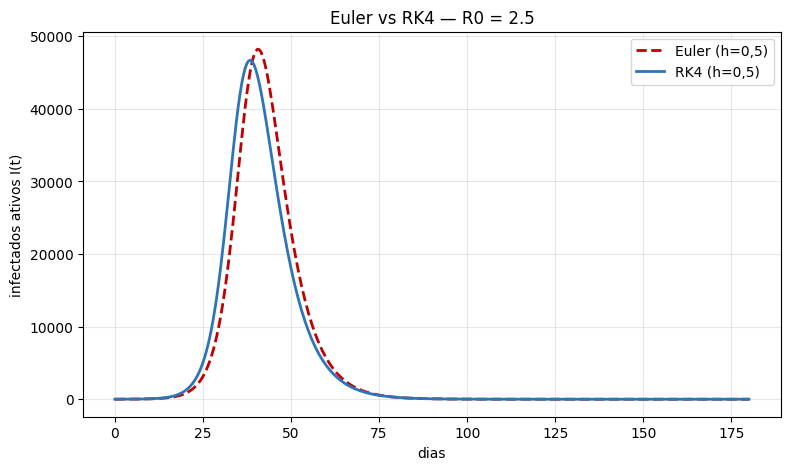

Pico Euler: 48,206 no dia 40.5
Pico RK4:   46,691 no dia 38.5


In [20]:
R0_central = 2.5
beta_central = R0_central * gamma
f = make_sir(beta_central)

h = 0.5
n = int(T_DAYS / h)

t_euler, y_euler = euler_explicit(f, 0.0, y0, h, n)
t_rk4,   y_rk4   = rk4(f, 0.0, y0, h, n)

# y[:, 1] é o compartimento I (infectados ativos)
I_euler = y_euler[:, 1]
I_rk4   = y_rk4[:, 1]

fig, ax = plt.subplots()
ax.plot(t_euler, I_euler, "--", color="#C00000", lw=2, label="Euler (h=0,5)")
ax.plot(t_rk4,   I_rk4,   "-",  color="#2E75B6", lw=2, label="RK4 (h=0,5)")
ax.set_xlabel("dias"); ax.set_ylabel("infectados ativos I(t)")
ax.set_title(f"Euler vs RK4 — R0 = {R0_central}")
ax.legend(); plt.show()

print(f"Pico Euler: {I_euler.max():,.0f} no dia {t_euler[I_euler.argmax()]:.1f}")
print(f"Pico RK4:   {I_rk4.max():,.0f} no dia {t_rk4[I_rk4.argmax()]:.1f}")

### 3.1 Quão errado está o Euler?

Não temos solução exata, mas podemos usar **RK4 com passo muito fino** como referência
("verdade" numérica) e medir o erro de cada método com $h = 0{,}5$ contra ela.
O erro é avaliado no pico, que é a grandeza que decide o número de leitos.

In [21]:
# referência: RK4 com passo fino
h_ref = 0.01
n_ref = int(T_DAYS / h_ref)
t_ref, y_ref = rk4(f, 0.0, y0, h_ref, n_ref)
I_ref = y_ref[:, 1]

pico_ref = I_ref.max()
dia_ref  = t_ref[I_ref.argmax()]
print(f"Referência (RK4 h={h_ref}): pico {pico_ref:,.0f} no dia {dia_ref:.2f}")
print()

for nome, Ia, ta in [("Euler", I_euler, t_euler), ("RK4", I_rk4, t_rk4)]:
    err_pico = abs(Ia.max() - pico_ref)
    err_dia  = abs(ta[Ia.argmax()] - dia_ref)
    print(f"{nome:6s} (h={h}): erro no pico = {err_pico:8,.0f} pessoas | "
          f"erro na data = {err_dia:.2f} dias")

Referência (RK4 h=0.01): pico 46,698 no dia 38.39

Euler  (h=0.5): erro no pico =    1,508 pessoas | erro na data = 2.11 dias
RK4    (h=0.5): erro no pico =        7 pessoas | erro na data = 0.11 dias


### 3.2 Custo para a mesma precisão

O ponto prático: **quantas avaliações de $f$** cada método precisa para errar o pico
em menos de ~50 pessoas? É isso que diferencia $O(h)$ de $O(h^4)$.

In [22]:
def avaliacoes_para_precisao(metodo, mult, tol=50.0, hs=None):
    """Menor número de avaliações de f para |pico - pico_ref| < tol.

    mult = nº de chamadas a f por passo (Euler=1, RK4=4).
    """
    if hs is None:
        hs = [1.0, 0.5, 0.25, 0.1, 0.05, 0.025, 0.01, 0.005, 0.0025, 0.001]
    for h_test in hs:
        n_test = int(T_DAYS / h_test)
        _, y = metodo(f, 0.0, y0, h_test, n_test)
        if abs(y[:, 1].max() - pico_ref) < tol:
            return h_test, n_test * mult
    return None, None

h_e, ev_e = avaliacoes_para_precisao(euler_explicit, mult=1)
h_r, ev_r = avaliacoes_para_precisao(rk4,            mult=4)

print(f"Euler: h={h_e}  ->  {ev_e:,} avaliações de f")
print(f"RK4:   h={h_r}  ->  {ev_r:,} avaliações de f")
if ev_e and ev_r:
    print(f"\nRK4 usa ~{ev_e/ev_r:.0f}x menos avaliações para a mesma precisão.")

Euler: h=0.01  ->  18,000 avaliações de f
RK4:   h=0.5  ->  1,440 avaliações de f

RK4 usa ~12x menos avaliações para a mesma precisão.


## 4. Análise de sensibilidade — três valores de $R_0$

Como $R_0$ tem incerteza (2,0 a 2,8), rodamos o cenário otimista, central e pessimista.
Daqui em diante usamos **RK4** (já justificado como o método confiável).

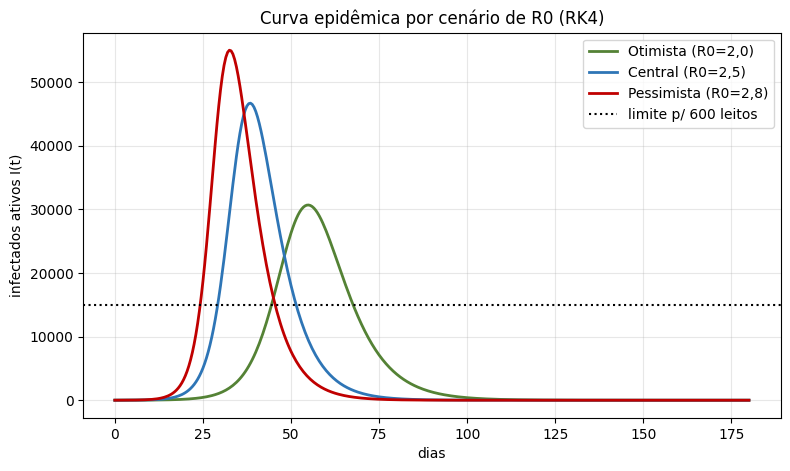

In [23]:
cenarios = {
    "Otimista (R0=2,0)":   2.0,
    "Central (R0=2,5)":    2.5,
    "Pessimista (R0=2,8)": 2.8,
}
cores = {"Otimista (R0=2,0)": "#548235",
         "Central (R0=2,5)":  "#2E75B6",
         "Pessimista (R0=2,8)": "#C00000"}

h = 0.5
n = int(T_DAYS / h)
resultados = {}

fig, ax = plt.subplots()
for nome, R0 in cenarios.items():
    f_c = make_sir(R0 * gamma)
    t, y = rk4(f_c, 0.0, y0, h, n)
    I = y[:, 1]
    ipk = I.argmax()
    resultados[nome] = {
        "R0": R0,
        "pico": I.max(),
        "dia_pico": t[ipk],
        "leitos": HOSP_RATE * I.max(),
        "ataque_final": y[-1, 2] / N,
    }
    ax.plot(t, I, lw=2, color=cores[nome], label=nome)

ax.axhline(BEDS / HOSP_RATE, color="black", ls=":", lw=1.5,
           label=f"limite p/ {BEDS} leitos")
ax.set_xlabel("dias"); ax.set_ylabel("infectados ativos I(t)")
ax.set_title("Curva epidêmica por cenário de R0 (RK4)")
ax.legend(); plt.show()

In [24]:
# tabela-resumo
print(f"{'Cenário':22s} {'Pico I(t)':>12s} {'Leitos (4%)':>12s} "
      f"{'Dia do pico':>12s} {'Ataque final':>13s}")
print("-" * 75)
for nome, r in resultados.items():
    print(f"{nome:22s} {r['pico']:12,.0f} {r['leitos']:12,.0f} "
          f"{r['dia_pico']:12.1f} {r['ataque_final']*100:12.1f}%")

Cenário                   Pico I(t)  Leitos (4%)  Dia do pico  Ataque final
---------------------------------------------------------------------------
Otimista (R0=2,0)            30,683        1,227         55.0         79.7%
Central (R0=2,5)             46,691        1,868         38.5         89.3%
Pessimista (R0=2,8)          55,013        2,201         32.5         92.5%


## 4. Conclusão

- O termo não-linear $\beta\,SI/N$ impede solução fechada; foi preciso integrar numericamente.
- Com o **mesmo passo**, o Euler erra o pico (a grandeza que decide leitos) muito mais que o RK4,
  e tende a *passar do ponto* perto do máximo. Para a mesma precisão, o Euler precisa de
  ordens de magnitude mais avaliações de $f$.
- O **RK4** (Burden, Seç. 5.9, estendido a sistemas via vetor $\mathbf{y}=[S,I,R]$) entrega a
  curva $I(t)$ confiável que torna o modelo operacional para a decisão.
- A validação pela equação transcendental confirma o tamanho final da epidemia.

**A sinergia:** o SIR fornece a *estrutura conceitual* (compartimentos, $R_0$, freio da imunidade);
o RK4 fornece o *cálculo numérico confiável*. Sem integrar o sistema, há apenas equações no papel.